# Multi-Class Prediction of Obesity Risk - Obezite Riskinin Çok Sınıflı Tahmini

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR6Nk5scEc0yzTjHTgtWkW-n5-o7AyNhDMmxuHAEOs1vg&s">

Bu projenin amacı, bireylerin demografik özellikleri, beslenme alışkanlıkları ve yaşam tarzı bilgilerini kullanarak obezite risk seviyelerini tahmin etmektir. Makine öğrenmesi sınıflandırma algoritmaları kullanılarak bireylerin hangi obezite kategorisinde yer aldığı belirlenmeye çalışılmıştır. Elde edilen sonuçlar sayesinde obezite riskinin erken tespit edilmesi ve sağlıklı yaşam konusunda farkındalık oluşturulması hedeflenmektedir.

### Sütun Açıklamaları

**id**: Her bir gözlem için benzersiz kimlik numarasıdır. Model eğitiminde tahmin gücü olmadığı için genellikle veri setinden çıkarılır.

**Gender**: Bireyin cinsiyet bilgisini ifade eder (Male/Female).

**Age**: Bireyin yaşını göstermektedir.

**Height**: Bireyin boy bilgisidir (metre cinsinden).

**Weight**: Bireyin ağırlık bilgisidir (kilogram cinsinden).

**family_history_with_overweight**: Ailede fazla kilo veya obezite geçmişi olup olmadığını gösterir (yes/no).

**FAVC**: Bireyin yüksek kalorili yiyecekleri sık tüketip tüketmediğini belirtir (yes/no).

**FCVC**: Günlük sebze tüketim sıklığını ifade eder. Yüksek değerler daha fazla sebze tüketimini gösterir.

**NCP**: Gün içerisinde tüketilen ana öğün sayısını belirtir.

**CAEC**: Ana öğünler arasında atıştırmalık tüketim sıklığını ifade eder.
- No: Hiç
- Sometimes: Bazen
- Frequently: Sık sık
- Always: Her zaman

**SMOKE**: Bireyin sigara kullanıp kullanmadığını gösterir (yes/no).

**CH2O**: Günlük su tüketim miktarını ifade eder. Değer yükseldikçe su tüketimi artmaktadır.

**SCC**: Kalori tüketimini takip edip etmediğini gösterir (yes/no).

**FAF**: Haftalık fiziksel aktivite düzeyini ifade eder. Yüksek değerler daha fazla fiziksel aktiviteyi göstermektedir.

**TUE**: Teknolojik cihazlar (telefon, bilgisayar, tablet vb.) karşısında geçirilen süreyi ifade eder.

**CALC**: Alkol tüketim sıklığını belirtir.
- No: Hiç
- Sometimes: Bazen
- Frequently: Sık sık
- Always: Her zaman

**MTRANS**: Günlük hayatta kullanılan ulaşım türünü ifade eder.
- Walking: Yürüyüş
- Bike: Bisiklet
- Motorbike: Motosiklet
- Public_Transportation: Toplu taşıma
- Automobile: Otomobil

**NObeyesdad**: Hedef değişkendir (target). Bireyin obezite seviyesini göstermektedir.
- Insufficient_Weight: Düşük kilolu
- Normal_Weight: Normal kilolu
- Overweight_Level_I: Fazla kilolu Seviye I
- Overweight_Level_II: Fazla kilolu Seviye II
- Obesity_Type_I: Obezite Tip I
- Obesity_Type_II: Obezite Tip II
- Obesity_Type_III: Obezite Tip III

### Veri seti linki

https://www.kaggle.com/competitions/playground-series-s4e2/data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s4e2/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e2/train.csv
/kaggle/input/competitions/playground-series-s4e2/test.csv


In [2]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ön işleme
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Classification Modelleri
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

# Performans Metrikleri
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Uyarıları kapatmak için (isteğe bağlı)
import warnings
warnings.filterwarnings("ignore")# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ön işleme
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Classification Modelleri
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

# Performans Metrikleri
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Uyarıları kapatmak için (isteğe bağlı)
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s4e2/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e2/train.csv
/kaggle/input/competitions/playground-series-s4e2/test.csv


In [6]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e2/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s4e2/test.csv")

In [7]:
train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [8]:
train.columns

Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [10]:
train.isnull().sum()

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [11]:
train.describe()

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


In [12]:
train.shape

(20758, 18)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Kategorik sütunları bul
cat_cols = train.select_dtypes(include="object").columns

cat_cols

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [15]:
from sklearn.preprocessing import LabelEncoder

cat_cols = train.select_dtypes(include="object").columns

for col in cat_cols:
    if col != "NObeyesdad":
        le = LabelEncoder()
        combined = pd.concat([train[col], test[col]], axis=0)
        le.fit(combined)

        train[col] = le.transform(train[col])
        test[col] = le.transform(test[col])

# Hedef değişkeni ayrıca encode ediyoruz
le_target = LabelEncoder()
train["NObeyesdad"] = le_target.fit_transform(train["NObeyesdad"])

In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  int64  
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  int64  
 10  SMOKE                           20758 non-null  int64  
 11  CH2O                            20758 non-null  float64
 12  SCC                             

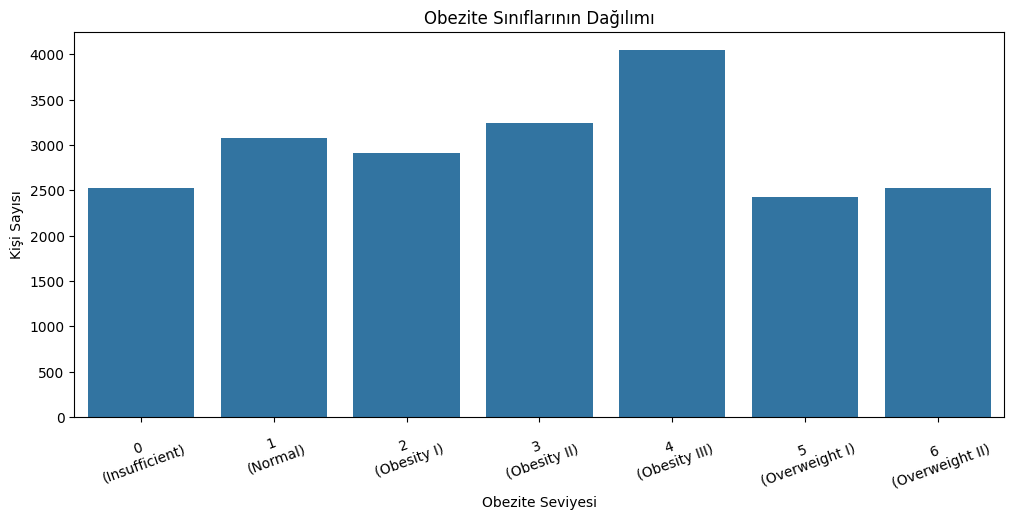

In [35]:
plt.figure(figsize=(12,5))

etiketler = [
    "0\n(Insufficient)",
    "1\n(Normal)",
    "2\n(Obesity I)",
    "3\n(Obesity II)",
    "4\n(Obesity III)",
    "5\n(Overweight I)",
    "6\n(Overweight II)"
]

sns.countplot(x="NObeyesdad", data=train)
plt.xticks(ticks=range(len(etiketler)), labels=etiketler, rotation=20)

plt.title("Obezite Sınıflarının Dağılımı")
plt.xlabel("Obezite Seviyesi")
plt.ylabel("Kişi Sayısı")

plt.show()

Veri setinde en yoğun grup Obesity Type III, en az yoğun gruplar ise Overweight Level I, Overweight Level II ve Insufficient Weight sınıflarıdır. Sınıfların genel olarak dengeli dağılması, model performansını olumlu yönde etkileyen önemli bir özelliktir.

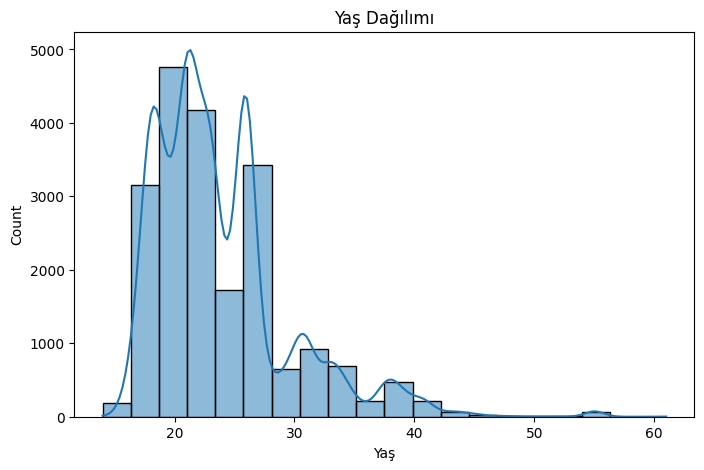

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(train["Age"], bins=20, kde=True)
plt.title("Yaş Dağılımı")
plt.xlabel("Yaş")
plt.show()

Grafik incelendiğinde veri setindeki bireylerin büyük çoğunluğunun 18-30 yaş aralığında toplandığı görülmektedir. Özellikle 20-25 yaş arası yoğunluk oldukça yüksektir. 40 yaş üzerindeki birey sayısı belirgin şekilde azalmaktadır. Bu durum veri setinin ağırlıklı olarak genç bireylerden oluştuğunu göstermektedir.

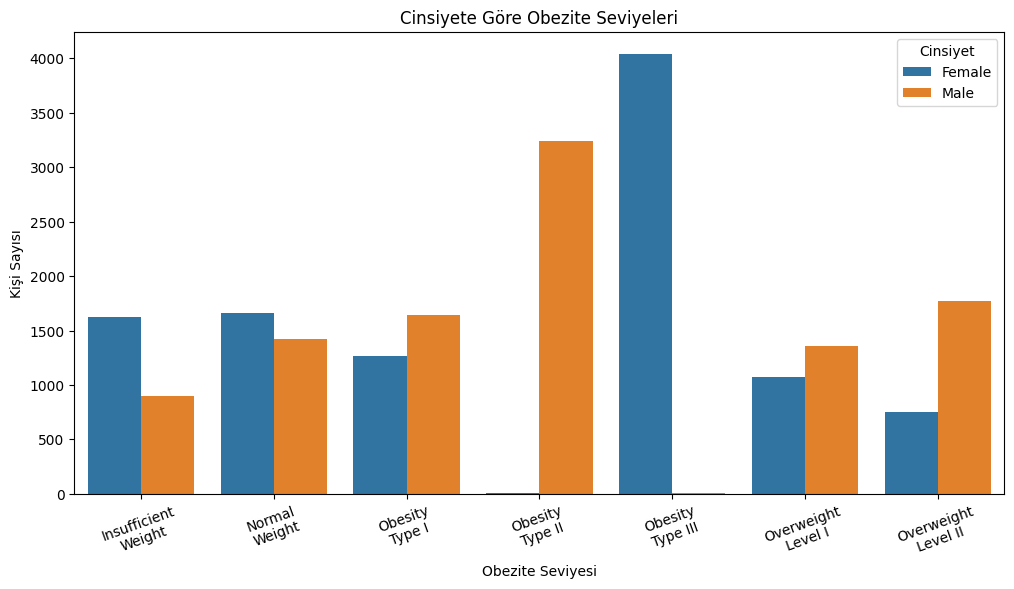

In [36]:
plt.figure(figsize=(12,6))

etiketler = [
    "Insufficient\nWeight",
    "Normal\nWeight",
    "Obesity\nType I",
    "Obesity\nType II",
    "Obesity\nType III",
    "Overweight\nLevel I",
    "Overweight\nLevel II"
]

ax = sns.countplot(
    x="NObeyesdad",
    hue="Gender",
    data=train
)

plt.xticks(
    ticks=range(len(etiketler)),
    labels=etiketler,
    rotation=20
)

plt.xlabel("Obezite Seviyesi")
plt.ylabel("Kişi Sayısı")
plt.title("Cinsiyete Göre Obezite Seviyeleri")

plt.legend(
    title="Cinsiyet",
    labels=["Female", "Male"]
)

plt.show()

Kadın bireyler daha çok düşük kilolu, normal kilolu ve Obesity Type III sınıflarında yoğunlaşırken, erkek bireyler Obesity Type I, Obesity Type II ve fazla kilolu (Overweight) sınıflarında daha yüksek sayıda temsil edilmektedir. Bu nedenle cinsiyet değişkeni ile obezite seviyesi arasında anlamlı bir ilişki olduğu söylenebilir.

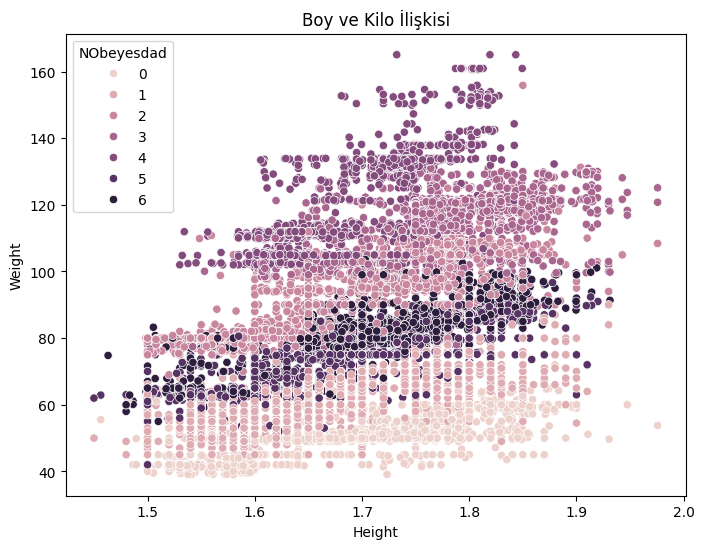

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Height",
    y="Weight",
    hue="NObeyesdad",
    data=train
)
plt.title("Boy ve Kilo İlişkisi")
plt.show()

Bu grafik veri setindeki en anlamlı ilişkilerden birini göstermektedir. Boy arttıkça ağırlığın da genel olarak arttığı görülmektedir. Ayrıca obezite seviyesi yükseldikçe bireylerin daha yüksek ağırlık değerlerinde kümelendiği dikkat çekmektedir. Özellikle aynı boy aralığında yer alan bireylerin farklı kilo değerlerine sahip olması, obezite sınıflarının oluşumunda kilonun önemli bir belirleyici olduğunu göstermektedir.

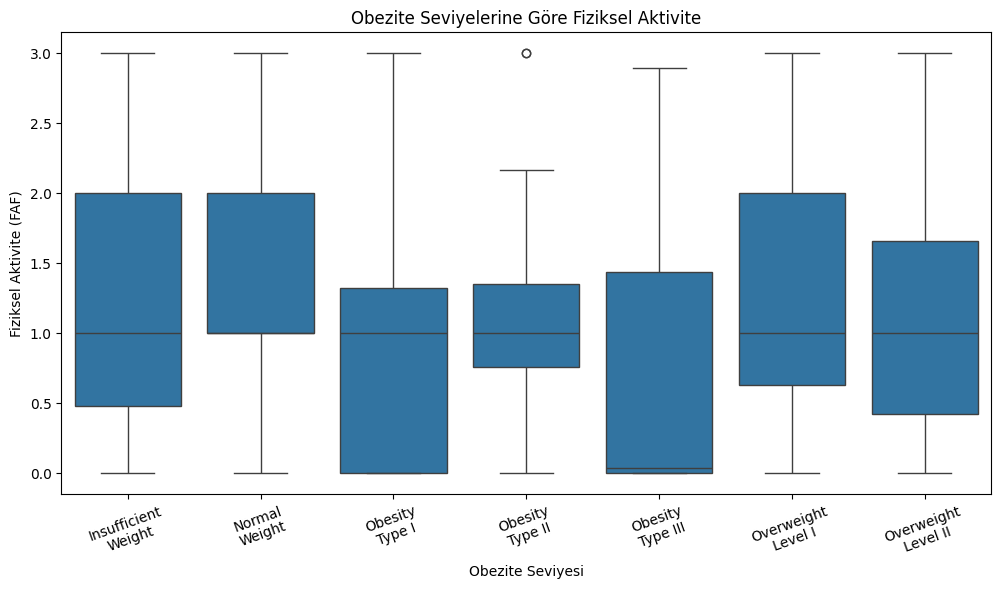

In [37]:
plt.figure(figsize=(12,6))

etiketler = [
    "Insufficient\nWeight",
    "Normal\nWeight",
    "Obesity\nType I",
    "Obesity\nType II",
    "Obesity\nType III",
    "Overweight\nLevel I",
    "Overweight\nLevel II"
]

sns.boxplot(
    x="NObeyesdad",
    y="FAF",
    data=train
)

plt.xticks(
    ticks=range(len(etiketler)),
    labels=etiketler,
    rotation=20
)

plt.xlabel("Obezite Seviyesi")
plt.ylabel("Fiziksel Aktivite (FAF)")
plt.title("Obezite Seviyelerine Göre Fiziksel Aktivite")

plt.show()

Fiziksel aktivite düzeyi ile obezite arasında ters yönlü bir ilişki gözlenmektedir. Daha aktif bireylerin normal kilolu olma eğilimi daha yüksekken, düşük fiziksel aktivite seviyeleri obezite riskini artırabilmektedir. Bununla birlikte obezite oluşumu çok sayıda faktörün birlikte etkisiyle gerçekleşmektedir.

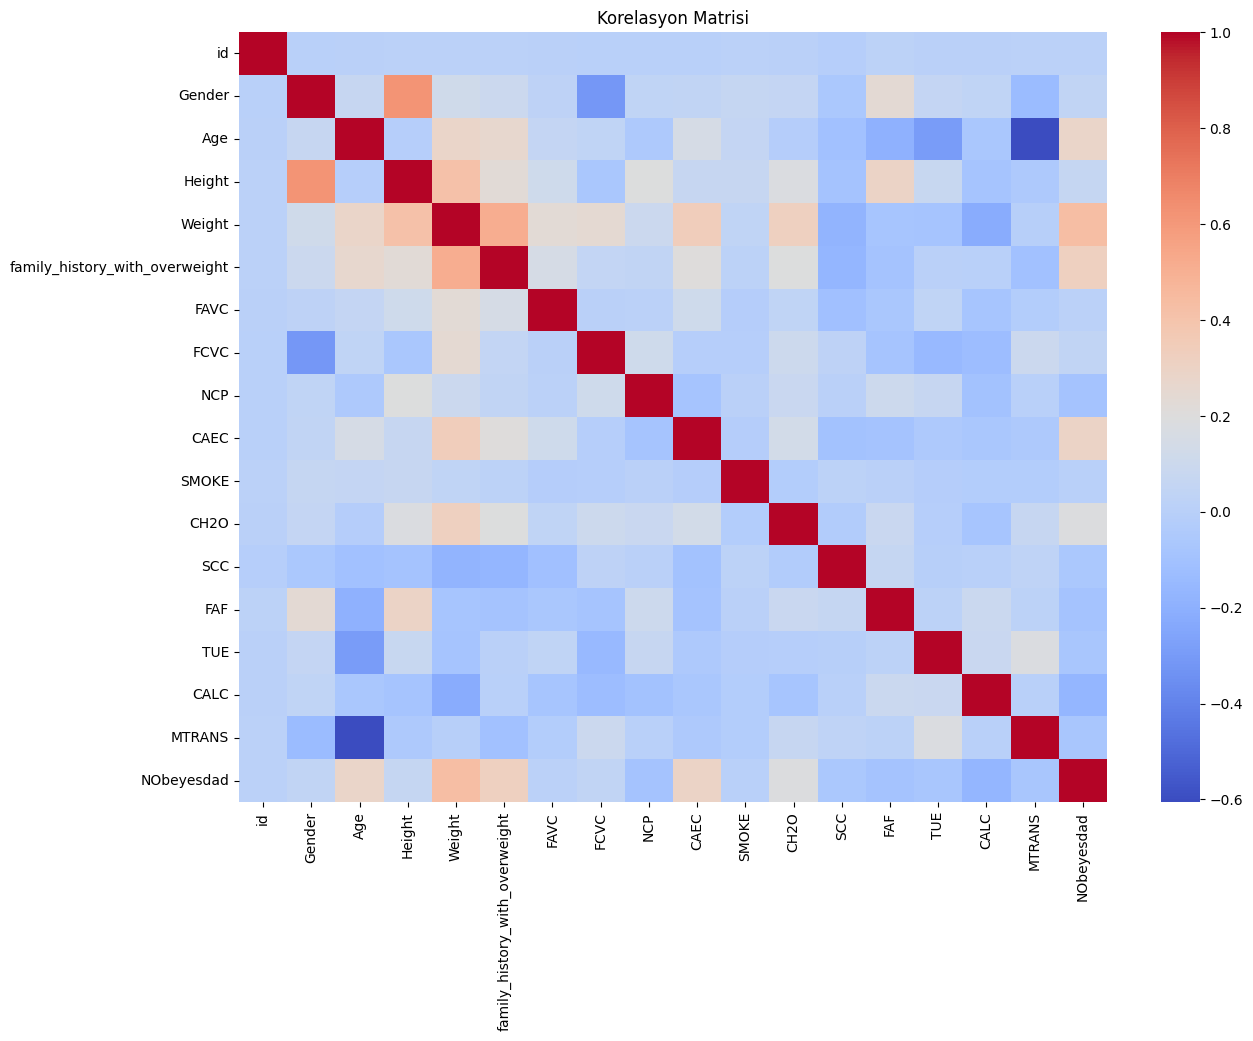

In [34]:
plt.figure(figsize=(14,10))
sns.heatmap(
    train.corr(),
    cmap="coolwarm"
)
plt.title("Korelasyon Matrisi")
plt.show()

Korelasyon matrisi değişkenler arasındaki doğrusal ilişkileri göstermektedir. Grafik incelendiğinde:

Weight (Kilo) ile NObeyesdad (Obezite Seviyesi) arasında pozitif yönde görece güçlü bir ilişki bulunmaktadır.
family_history_with_overweight değişkeni ile obezite seviyesi arasında pozitif ilişki görülmektedir.
Height (Boy) ile Weight (Kilo) arasında pozitif ilişki bulunmaktadır.
Değişkenlerin büyük çoğunluğu arasında düşük veya orta düzeyde korelasyon bulunmaktadır.
Çok yüksek korelasyonlu değişkenlerin bulunmaması, veri setinde ciddi bir çoklu doğrusal bağlantı (multicollinearity) problemi olmadığını göstermektedir.

In [17]:
x = train.drop(["id", "NObeyesdad"], axis=1)
y = train["NObeyesdad"]

In [18]:
print(x.shape)
print(y.shape)

(20758, 16)
(20758,)


In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

model_lr = lr.fit(x_train, y_train)

tahmin_lr = model_lr.predict(x_test)

print("Accuracy:", accuracy_score(y_test, tahmin_lr))
print("Precision:", precision_score(y_test, tahmin_lr, average="weighted"))
print("Recall:", recall_score(y_test, tahmin_lr, average="weighted"))
print("F1 Score:", f1_score(y_test, tahmin_lr, average="weighted"))

Accuracy: 0.8273121387283237
Precision: 0.8226621010085785
Recall: 0.8273121387283237
F1 Score: 0.8243631218795493


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

model_dt = dt.fit(x_train, y_train)

tahmin_dt = model_dt.predict(x_test)

print("Accuracy:", accuracy_score(y_test, tahmin_dt))
print("Precision:", precision_score(y_test, tahmin_dt, average="weighted"))
print("Recall:", recall_score(y_test, tahmin_dt, average="weighted"))
print("F1 Score:", f1_score(y_test, tahmin_dt, average="weighted"))

Accuracy: 0.8473025048169557
Precision: 0.8475461742424947
Recall: 0.8473025048169557
F1 Score: 0.8474086145610414


In [25]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(random_state=42)

model_et = et.fit(x_train, y_train)

tahmin_et = model_et.predict(x_test)

print("Accuracy:", accuracy_score(y_test, tahmin_et))
print("Precision:", precision_score(y_test, tahmin_et, average="weighted"))
print("Recall:", recall_score(y_test, tahmin_et, average="weighted"))
print("F1 Score:", f1_score(y_test, tahmin_et, average="weighted"))

Accuracy: 0.8783718689788054
Precision: 0.8786437324161702
Recall: 0.8783718689788054
F1 Score: 0.8782192784454055


In [26]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

model_gb = gb.fit(x_train, y_train)

tahmin_gb = model_gb.predict(x_test)

print("Accuracy:", accuracy_score(y_test, tahmin_gb))
print("Precision:", precision_score(y_test, tahmin_gb, average="weighted"))
print("Recall:", recall_score(y_test, tahmin_gb, average="weighted"))
print("F1 Score:", f1_score(y_test, tahmin_gb, average="weighted"))

Accuracy: 0.9026974951830443
Precision: 0.9028772612666218
Recall: 0.9026974951830443
F1 Score: 0.902776803441786


In [27]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

model_nb = nb.fit(x_train, y_train)

tahmin_nb = model_nb.predict(x_test)

print("Accuracy:", accuracy_score(y_test, tahmin_nb))
print("Precision:", precision_score(y_test, tahmin_nb, average="weighted"))
print("Recall:", recall_score(y_test, tahmin_nb, average="weighted"))
print("F1 Score:", f1_score(y_test, tahmin_nb, average="weighted"))

Accuracy: 0.6630539499036608
Precision: 0.6698539020261394
Recall: 0.6630539499036608
F1 Score: 0.6442635625261026


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd

def algo_test_classification(x, y):

    LR = LogisticRegression(max_iter=1000)
    NB = GaussianNB()
    GB = GradientBoostingClassifier(random_state=42)
    ET = ExtraTreesClassifier(random_state=42)
    DT = DecisionTreeClassifier(random_state=42)

    algos = [LR, NB, GB, ET, DT]

    algo_names = [
        "Logistic Regression",
        "Naive Bayes",
        "Gradient Boosting",
        "Extra Trees",
        "Decision Tree"
    ]

    accuracy = []
    precision = []
    recall = []
    f1 = []

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.20, random_state=42
    )

    for algo in algos:

        p = algo.fit(x_train, y_train).predict(x_test)

        accuracy.append(accuracy_score(y_test, p))
        precision.append(precision_score(y_test, p, average="weighted"))
        recall.append(recall_score(y_test, p, average="weighted"))
        f1.append(f1_score(y_test, p, average="weighted"))

    sonuc = pd.DataFrame({
        "Algorithm": algo_names,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    return sonuc.sort_values("Accuracy", ascending=False)

algo_test_classification(x, y)

,Algorithm,Accuracy,Precision,Recall,F1 Score
2,Gradient Boosting,0.902697,0.902877,0.902697,0.902777
3,Extra Trees,0.878372,0.878644,0.878372,0.878219
4,Decision Tree,0.847303,0.847546,0.847303,0.847409
0,Logistic Regression,0.827312,0.822662,0.827312,0.824363
1,Naive Bayes,0.663054,0.669854,0.663054,0.644264


## Sonuç

Bu çalışmada obezite risk seviyelerinin tahmini için beş farklı sınıflandırma algoritması uygulanmış ve performansları karşılaştırılmıştır. Elde edilen sonuçlara göre Gradient Boosting modeli %90,27 doğruluk oranı ile en başarılı algoritma olmuştur. Bu modeli sırasıyla Extra Trees (%87,84) ve Decision Tree (%84,73) takip etmiştir. Logistic Regression kabul edilebilir bir performans sergilerken, Naive Bayes modeli diğer algoritmalara göre daha düşük başarı göstermiştir. Genel olarak, veri setindeki karmaşık ilişkileri daha iyi yakalayabilen ağaç tabanlı yöntemlerin daha yüksek performans verdiği görülmüş ve bu problem için en uygun modelin Gradient Boosting Classifier olduğu sonucuna ulaşılmıştır.